In [3]:
import pandas as pd
df = pd.read_csv("vendor_registry.csv")
df_label = pd.read_csv("vendor_labels.csv")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from datetime import datetime

# Fixed 3x3 grid layout - block (row, col) -> feature name
# This mapping is the single source of truth for explainability
BLOCK_LAYOUT = {
    (0, 0): "risk_score",
    (0, 1): "breach_status",
    (0, 2): "compliance_certifications",
    (1, 0): "contract_days_left",
    (1, 1): "annual_spend",
    (1, 2): "data_access_scope",
    (2, 0): "audit_days_since",
    (2, 1): "vendor_type",
    (2, 2): "audit_to_contract_risk",   # composite/synthetic 9th feature
}

FEATURE_TO_BLOCK = {v: k for k, v in BLOCK_LAYOUT.items()}

PATCH_SIZE = 16   # 16x16 pixels per block
GRID = 3
IMG_SIZE = PATCH_SIZE * GRID   # 48

In [5]:
def engineer_features(df):
    out = pd.DataFrame()
    out["vendor_id"] = df["vendor_id"]

    # 1. risk_score - already numeric 0-100
    out["risk_score"] = df["risk_score"].astype(float)

    # 2. breach_status - categorical -> ordinal severity encoding
    breach_map = {"none": 0, "historical": 1, "suspected": 2, "confirmed": 3}
    out["breach_status"] = df["breach_status"].str.lower().map(breach_map).fillna(0)

    # 3. compliance_certifications - count number of certs present (text/list field)
    def cert_count(x):
        if pd.isna(x) or x == "":
            return 0
        return len(str(x).split(","))
    out["compliance_certifications"] = df["compliance_certifications"].apply(cert_count)

    # 4. contract_end_date -> days remaining from today
    today = pd.Timestamp(datetime.now().date())
    contract_end = pd.to_datetime(df["contract_end_date"], errors="coerce")
    out["contract_days_left"] = (contract_end - today).dt.days

    # 5. annual_spend - numeric
    out["annual_spend"] = df["annual_spend"].astype(float)

    # 6. data_access_scope - categorical -> ordinal
    scope_map = {"none": 0, "limited": 1, "moderate": 2, "full": 3}
    out["data_access_scope"] = df["data_access_scope"].str.lower().map(scope_map).fillna(0)

    # 7. last_audit_date -> days since audit
    last_audit = pd.to_datetime(df["last_audit_date"], errors="coerce")
    out["audit_days_since"] = (today - last_audit).dt.days

    # 8. vendor_type - categorical -> ordinal/frequency encode
    out["vendor_type"] = df["vendor_type"].astype("category").cat.codes

    # 9. composite synthetic feature: audit staleness vs contract urgency
    # high value = stale audit AND contract renewing soon (compounding risk)
    out["audit_to_contract_risk"] = (
        out["audit_days_since"].clip(lower=0) /
        (out["contract_days_left"].clip(lower=1))
    )

    return out

features_df = engineer_features(df)
features_df.describe()

,risk_score,breach_status,compliance_certifications,contract_days_left,annual_spend,data_access_scope,audit_days_since,vendor_type,audit_to_contract_risk
count,400.000000,400.0,400.0,400.000000,4.000000e+02,400.0,400.0000,400.000000,400.000000
mean,55.750000,0.0,1.0,271.592500,2.394673e+06,0.0,252.3225,3.920000,34.238626
std,26.613496,0.0,0.0,217.224187,1.410857e+06,0.0,98.2391,2.558312,90.410786
min,10.000000,0.0,1.0,-92.000000,1.508200e+04,0.0,93.0000,0.000000,0.153727
25%,33.000000,0.0,1.0,86.750000,1.133505e+06,0.0,164.7500,2.000000,0.552229
50%,55.000000,0.0,1.0,259.500000,2.349057e+06,0.0,249.0000,4.000000,0.950690
75%,79.250000,0.0,1.0,462.250000,3.662949e+06,0.0,336.0000,6.000000,2.688106
max,99.000000,0.0,1.0,665.000000,4.980008e+06,0.0,426.0000,8.000000,415.000000


In [6]:
FEATURE_COLS = list(FEATURE_TO_BLOCK.keys())

norm_params = {}
for col in FEATURE_COLS:
    lo = features_df[col].quantile(0.01)
    hi = features_df[col].quantile(0.99)
    norm_params[col] = (lo, hi)

def normalize_row(row):
    normed = {}
    for col in FEATURE_COLS:
        lo, hi = norm_params[col]
        val = row[col]
        if hi == lo:
            normed[col] = 0.5
        else:
            normed[col] = np.clip((val - lo) / (hi - lo), 0, 1)
    return normed

/tmp/ipykernel_589327/3017914735.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


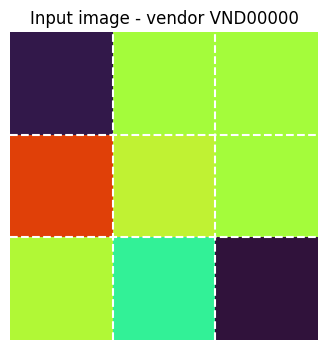

In [7]:
def build_input_image(row, colormap="turbo"):
    normed = normalize_row(row)
    cmap = cm.get_cmap(colormap)

    img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    for (r, c), feat_name in BLOCK_LAYOUT.items():
        val = normed[feat_name]                  # 0-1
        rgba = cmap(val)                          # smooth color from colormap
        rgb = (np.array(rgba[:3]) * 255).astype(np.uint8)

        y0, y1 = r * PATCH_SIZE, (r + 1) * PATCH_SIZE
        x0, x1 = c * PATCH_SIZE, (c + 1) * PATCH_SIZE
        img[y0:y1, x0:x1] = rgb   # solid colored tile

    return img

# Quick test on one vendor
sample_row = features_df.iloc[0]
sample_img = build_input_image(sample_row)

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.axvline(15.5, color="white", linewidth=1.5, linestyle="--")
plt.axvline(31.5, color="white", linewidth=1.5, linestyle="--")
plt.axhline(15.5, color="white", linewidth=1.5, linestyle="--")
plt.axhline(31.5, color="white", linewidth=1.5, linestyle="--")
plt.title(f"Input image - vendor {features_df.iloc[0]['vendor_id']}")
plt.axis("off")
plt.show()

In [8]:
# Map each anomaly_type to the block it should "light up"
ANOMALY_TO_BLOCK = {
    "EXPIRED_CERTIFICATION":          (0, 2),   # compliance_certifications
    "BREACHED_VENDOR_HIGH_ACCESS":    (0, 1),   # breach_status
    "RECENTLY_BREACHED_VENDOR":       (0, 1),   # breach_status
    "CONTRACT_EXPIRED_ACTIVE_ACCESS": (1, 0),   # contract_days_left
    "VENDOR_UNDER_INVESTIGATION":     (2, 2),   # audit_to_contract_risk (composite)
    "HIGH_RISK_SCORE":                (0, 0),   # risk_score
    "ELEVATED_RISK_VENDOR":           (0, 0),   # risk_score
    "LOW_RISK_VENDOR":                None,     # no hotspot - normal vendor
}

SEVERITY_WEIGHT = {"low": 0.4, "medium": 0.7, "high": 1.0, "critical": 1.0}

/tmp/ipykernel_589327/265777047.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


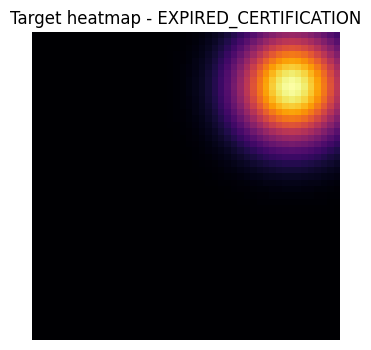

In [9]:
def gaussian_2d(center_y, center_x, sigma, size):
    y, x = np.meshgrid(np.arange(size), np.arange(size), indexing="ij")
    g = np.exp(-((y - center_y) ** 2 + (x - center_x) ** 2) / (2 * sigma ** 2))
    return g

def build_output_heatmap(label_row, colormap="inferno", sigma=6):
    intensity = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    is_anom = label_row["is_anomaly"]
    anomaly_type = label_row.get("anomaly_type", None)
    severity = str(label_row.get("severity", "low")).lower()
    weight = SEVERITY_WEIGHT.get(severity, 0.5)

    if is_anom and anomaly_type in ANOMALY_TO_BLOCK:
        block = ANOMALY_TO_BLOCK[anomaly_type]
        if block is not None:
            r, c = block
            center_y = r * PATCH_SIZE + PATCH_SIZE // 2
            center_x = c * PATCH_SIZE + PATCH_SIZE // 2
            intensity += weight * gaussian_2d(center_y, center_x, sigma, IMG_SIZE)

    # normalize to 0-1, then colorize
    if intensity.max() > 0:
        intensity = intensity / intensity.max()

    cmap = cm.get_cmap(colormap)
    rgba = cmap(intensity)
    heatmap_img = (rgba[:, :, :3] * 255).astype(np.uint8)

    return heatmap_img, intensity

# Quick test - pick a labeled anomalous vendor
sample_label_row = df_label.iloc[0]
hm_img, hm_raw = build_output_heatmap(sample_label_row)

plt.figure(figsize=(4, 4))
plt.imshow(hm_img)
plt.title(f"Target heatmap - {sample_label_row['anomaly_type']}")
plt.axis("off")
plt.show()

In [10]:
merged = df.merge(df_label, left_on="vendor_id", right_on="record_id", suffixes=("", "_label"))
features_df_merged = engineer_features(merged)

X = []
Y = []

for i in range(len(merged)):
    feat_row = features_df_merged.iloc[i]
    label_row = merged.iloc[i]

    x_img = build_input_image(feat_row)
    y_img, y_raw = build_output_heatmap(label_row)

    X.append(x_img)
    Y.append(y_raw)   # store raw intensity (0-1, single channel) for training target

X = np.array(X)            # shape: (N, 48, 48, 3)
Y = np.array(Y)            # shape: (N, 48, 48)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

/tmp/ipykernel_589327/3017914735.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)
/tmp/ipykernel_589327/265777047.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


X shape: (400, 48, 48, 3)
Y shape: (400, 48, 48)


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# X: (N, 48, 48, 3) uint8 -> normalize to 0-1, channels-first for PyTorch
X_norm = X.astype(np.float32) / 255.0
X_norm = np.transpose(X_norm, (0, 3, 1, 2))   # (N, 3, 48, 48)

# Y: (N, 48, 48) already 0-1 float -> add channel dim
Y_norm = Y.astype(np.float32)[:, np.newaxis, :, :]   # (N, 1, 48, 48)

X_train, X_val, Y_train, Y_val = train_test_split(
    X_norm, Y_norm, test_size=0.2, random_state=42
)

class VendorHeatmapDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_ds = VendorHeatmapDataset(X_train, Y_train)
val_ds   = VendorHeatmapDataset(X_val, Y_val)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Using device: cuda
Train: 320 | Val: 80


Normal-only training samples: 78
Full dataset (for scoring): 400
Params: 131,027
Params: 131,027
Params: 131,027
Params: 131,027
Epoch 1/300 | train: 0.08929 | val: 0.10614
Epoch 10/300 | train: 0.04731 | val: 0.04098
Epoch 20/300 | train: 0.01978 | val: 0.01758
Epoch 30/300 | train: 0.00903 | val: 0.00740
Epoch 40/300 | train: 0.00477 | val: 0.00390
Epoch 50/300 | train: 0.00298 | val: 0.00250
Epoch 60/300 | train: 0.00230 | val: 0.00157
Epoch 70/300 | train: 0.00160 | val: 0.00122
Epoch 80/300 | train: 0.00170 | val: 0.00112
Epoch 90/300 | train: 0.00136 | val: 0.00077
Epoch 100/300 | train: 0.00104 | val: 0.00059
Epoch 110/300 | train: 0.00089 | val: 0.00054
Epoch 120/300 | train: 0.00081 | val: 0.00047
Epoch 130/300 | train: 0.00074 | val: 0.00048
Epoch 140/300 | train: 0.00071 | val: 0.00042
Epoch 150/300 | train: 0.00056 | val: 0.00034
Epoch 160/300 | train: 0.00060 | val: 0.00033
Epoch 170/300 | train: 0.00070 | val: 0.00035
Epoch 180/300 | train: 0.00053 | val: 0.00029
Epoch 19

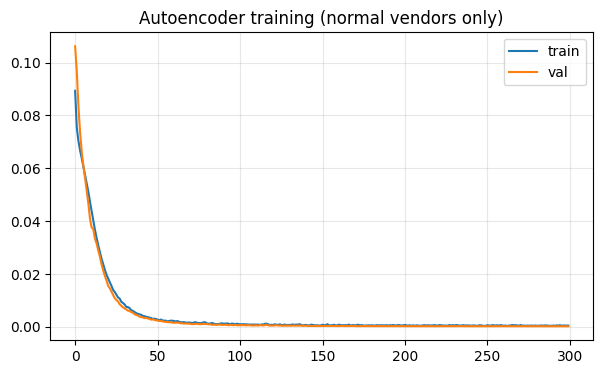

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- 1. Reuse your existing 48x48x3 input images (X from earlier) ----
X_norm = X.astype(np.float32) / 255.0
X_norm = np.transpose(X_norm, (0, 3, 1, 2))   # (N, 3, 48, 48)

# Important: train the autoencoder ONLY on vendors labeled "normal" (is_anomaly == False)
# so it learns what a clean vendor profile looks like, and anomalies show up as high error later.
is_anom_array = merged["is_anomaly"].values
X_normal = X_norm[~is_anom_array]
X_all = X_norm   # full set, used later for inference/error scoring

print(f"Normal-only training samples: {X_normal.shape[0]}")
print(f"Full dataset (for scoring): {X_all.shape[0]}")

X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

class ImageOnlyDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]

train_loader = DataLoader(ImageOnlyDataset(X_train), batch_size=8, shuffle=True)
val_loader   = DataLoader(ImageOnlyDataset(X_val), batch_size=8, shuffle=False)

# ---- 2. True autoencoder: input == output, same shape, same channels ----
class ConvAutoencoderTightBottleneck(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)   # 48 -> 24

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)   # 24 -> 12

        self.enc3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU()
        )
        self.pool3 = nn.MaxPool2d(2)   # 12 -> 6

        # ---- NEW: extra compression stage, narrower channels ----
        self.enc4 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU()
        )
        self.pool4 = nn.MaxPool2d(3)   # 6 -> 2   (tight bottleneck: 2x2x32 = 128 dims, vs old 6x6x64=2304)

        # ---- Decoder ----
        self.up0 = nn.ConvTranspose2d(32, 64, 3, stride=3)   # 2 -> 6 (undo pool4, no skip here - true bottleneck)

        self.up1 = nn.ConvTranspose2d(64, 64, 2, stride=2)   # 6 -> 12
        self.dec1 = nn.Sequential(
            nn.Conv2d(64 + 64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU()  # +skip from e3 (12x12, 64ch)
        )

        self.up2 = nn.ConvTranspose2d(32, 32, 2, stride=2)   # 12 -> 24
        self.dec2 = nn.Sequential(
            nn.Conv2d(32 + 32, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU()  # +skip from e2 (24x24, 32ch)
        )

        self.up3 = nn.ConvTranspose2d(16, 16, 2, stride=2)   # 24 -> 48
        self.dec3 = nn.Sequential(
            nn.Conv2d(16 + 16, 8, 3, padding=1), nn.BatchNorm2d(8), nn.ReLU()    # +skip from e1 (48x48, 16ch)
        )

        self.out_conv = nn.Conv2d(8, 3, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        e1 = self.enc1(x)        # (16, 48, 48)
        p1 = self.pool1(e1)      # (16, 24, 24)

        e2 = self.enc2(p1)       # (32, 24, 24)
        p2 = self.pool2(e2)      # (32, 12, 12)

        e3 = self.enc3(p2)       # (64, 12, 12)
        p3 = self.pool3(e3)      # (64, 6, 6)

        e4 = self.enc4(p3)       # (32, 6, 6)
        p4 = self.pool4(e4)      # (32, 2, 2)   <-- bottleneck, no skip connection here on purpose

        d0 = self.up0(p4)        # (64, 6, 6) - back up from the tight bottleneck

        d1 = self.up1(d0)                  # (64, 12, 12)
        d1 = torch.cat([d1, e3], dim=1)    # concat with e3 -> (128, 12, 12)
        d1 = self.dec1(d1)                 # -> (32, 12, 12)

        d2 = self.up2(d1)                  # (32, 24, 24)
        d2 = torch.cat([d2, e2], dim=1)    # concat with e2 -> (64, 24, 24)
        d2 = self.dec2(d2)                 # -> (16, 24, 24)

        d3 = self.up3(d2)                  # (16, 48, 48)
        d3 = torch.cat([d3, e1], dim=1)    # concat with e1 -> (32, 48, 48)
        d3 = self.dec3(d3)                 # -> (8, 48, 48)

        out = self.out_conv(d3)
        out = self.sigmoid(out)
        return out

model = ConvAutoencoderTightBottleneck().to(device)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

model = ConvAutoencoderTightBottleneck().to(device)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

# ---- 3. Train: reconstruct normal vendors only ----
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

EPOCHS = 300
best_val_loss = float("inf")
patience, patience_counter = 20, 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for xb in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        recon = model(xb)
        loss = criterion(recon, xb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb in val_loader:
            xb = xb.to(device)
            recon = model(xb)
            loss = criterion(recon, xb)
            val_running_loss += loss.item() * xb.size(0)
    val_loss = val_running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_autoencoder.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | train: {train_loss:.5f} | val: {val_loss:.5f}")

print(f"\nBest val loss (normal vendors only): {best_val_loss:.5f}")

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend(); plt.grid(alpha=0.3)
plt.title("Autoencoder training (normal vendors only)")
plt.show()

In [13]:
# ---- 4. Score ALL vendors (normal + anomalous) by reconstruction error ----
model.load_state_dict(torch.load("best_autoencoder.pt"))
model.eval()

X_all_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)

with torch.no_grad():
    recon_all = model(X_all_tensor).cpu().numpy()

# Per-vendor scalar error (mean squared error across whole image)
errors_per_vendor = ((X_all - recon_all) ** 2).mean(axis=(1, 2, 3))

# Per-vendor, per-block error map (this is your explainability heatmap)
def per_block_error(x_img, recon_img):
    """x_img, recon_img: (3, 48, 48). Returns dict block -> error"""
    block_err = {}
    for (r, c), feat_name in BLOCK_LAYOUT.items():
        y0, y1 = r * PATCH_SIZE, (r + 1) * PATCH_SIZE
        x0, x1 = c * PATCH_SIZE, (c + 1) * PATCH_SIZE
        diff = (x_img[:, y0:y1, x0:x1] - recon_img[:, y0:y1, x0:x1]) ** 2
        block_err[feat_name] = diff.mean()
    return block_err

results = []
for i in range(len(X_all)):
    block_errs = per_block_error(X_all[i], recon_all[i])
    top_feature = max(block_errs, key=block_errs.get)
    results.append({
        "vendor_id": merged.iloc[i]["vendor_id"],
        "is_anomaly_true": merged.iloc[i]["is_anomaly"],
        "anomaly_type_true": merged.iloc[i]["anomaly_type"],
        "reconstruction_error": errors_per_vendor[i],
        "top_error_feature": top_feature,
        **{f"err_{k}": v for k, v in block_errs.items()}
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("reconstruction_error", ascending=False)
results_df.head(20)

,vendor_id,is_anomaly_true,anomaly_type_true,reconstruction_error,top_error_feature,err_risk_score,err_breach_status,err_compliance_certifications,err_contract_days_left,err_annual_spend,err_data_access_scope,err_audit_days_since,err_vendor_type,err_audit_to_contract_risk
219,VND00219,True,HIGH_RISK_SCORE,0.000451,vendor_type,0.000816,0.000177,0.000143,0.000218,0.000366,0.000162,0.000360,0.001127,0.000687
18,VND00018,True,HIGH_RISK_SCORE,0.000451,audit_to_contract_risk,0.000250,0.000170,0.000139,0.000419,0.000844,0.000163,0.000495,0.000228,0.001346
6,VND00006,True,BREACHED_VENDOR_HIGH_ACCESS,0.000426,audit_to_contract_risk,0.000445,0.000192,0.000140,0.000216,0.000325,0.000184,0.000413,0.000755,0.001162
287,VND00287,True,EXPIRED_CERTIFICATION,0.000424,vendor_type,0.000477,0.000172,0.000140,0.000392,0.000766,0.000145,0.000808,0.000872,0.000046
180,VND00180,True,EXPIRED_CERTIFICATION,0.000418,audit_to_contract_risk,0.000609,0.000187,0.000140,0.000336,0.000423,0.000184,0.000590,0.000126,0.001165
88,VND00088,True,HIGH_RISK_SCORE,0.000404,audit_to_contract_risk,0.000698,0.000171,0.000139,0.000178,0.000245,0.000163,0.000524,0.000491,0.001030
70,VND00070,True,CONTRACT_EXPIRED_ACTIVE_ACCESS,0.000404,audit_to_contract_risk,0.000203,0.000165,0.000144,0.000165,0.000599,0.000178,0.000571,0.000312,0.001301
334,VND00334,True,HIGH_RISK_SCORE,0.000399,audit_to_contract_risk,0.000689,0.000177,0.000139,0.000340,0.000538,0.000157,0.000123,0.000273,0.001155
223,VND00223,True,VENDOR_UNDER_INVESTIGATION,0.000398,risk_score,0.000826,0.000179,0.000146,0.000773,0.000592,0.000164,0.000568,0.000241,0.000097
366,VND00366,True,EXPIRED_CERTIFICATION,0.000397,annual_spend,0.000915,0.000162,0.000139,0.000528,0.000932,0.000144,0.000624,0.000087,0.000039


                 count      mean       std       min       25%       50%  \
is_anomaly_true                                                            
False             78.0  0.000214  0.000054  0.000122  0.000181  0.000211   
True             322.0  0.000261  0.000066  0.000115  0.000212  0.000254   

                      75%       max  
is_anomaly_true                      
False            0.000242  0.000393  
True             0.000308  0.000451  


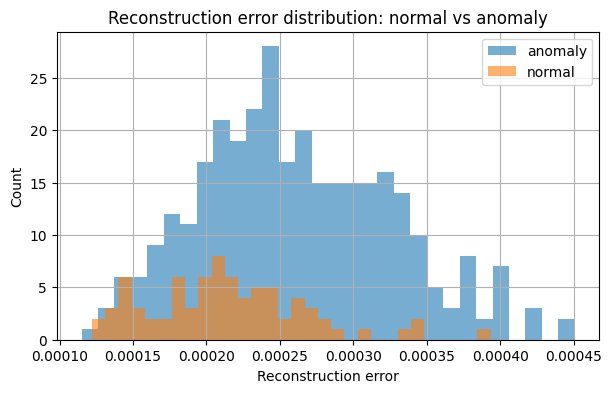

top_error_feature               annual_spend  audit_days_since  \
anomaly_type_true                                                
BREACHED_VENDOR_HIGH_ACCESS                6                10   
CONTRACT_EXPIRED_ACTIVE_ACCESS             0                 0   
ELEVATED_RISK_VENDOR                       4                 3   
EXPIRED_CERTIFICATION                     29                30   
HIGH_RISK_SCORE                           10                 7   
LOW_RISK_VENDOR                           17                18   
RECENTLY_BREACHED_VENDOR                   6                 9   
VENDOR_UNDER_INVESTIGATION                 3                 5   

top_error_feature               audit_to_contract_risk  breach_status  \
anomaly_type_true                                                       
BREACHED_VENDOR_HIGH_ACCESS                          2              0   
CONTRACT_EXPIRED_ACTIVE_ACCESS                       3              0   
ELEVATED_RISK_VENDOR                           

In [14]:
# ---- 5. Validate: do anomalies actually get higher reconstruction error? ----
print(results_df.groupby("is_anomaly_true")["reconstruction_error"].describe())

plt.figure(figsize=(7, 4))
results_df[results_df["is_anomaly_true"]]["reconstruction_error"].hist(bins=30, alpha=0.6, label="anomaly")
results_df[~results_df["is_anomaly_true"]]["reconstruction_error"].hist(bins=30, alpha=0.6, label="normal")
plt.xlabel("Reconstruction error")
plt.ylabel("Count")
plt.legend()
plt.title("Reconstruction error distribution: normal vs anomaly")
plt.show()

# Does top_error_feature align with the known anomaly cause?
print(pd.crosstab(results_df["anomaly_type_true"], results_df["top_error_feature"]))